<a href="https://colab.research.google.com/github/Manojkumar20-7/Aspect-Based-Sentiment-Analysis/blob/main/Model_Selection_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import warnings
warnings.filterwarnings("ignore")


In [15]:
import json
import pandas as pd

# Load the dataset from the JSON file
with open('new_dataset.json', 'r') as file:
    data = json.load(file)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Keep only the required columns for the project
required_columns = ['title', 'text', 'rating']
df_cleaned = df[required_columns]

# Display the cleaned DataFrame
df_cleaned.head()

,title,text,rating
0,Five Stars,Great value for price.,5.0
1,We are sooo happy to have ice again,We went almost a year without ice because ther...,5.0
2,Great Buy!,Work just as good as the more expensive brands...,5.0
3,Too expensive!,"Works great, tastes great but too expensive fo...",4.0
4,Says fits a Maytag but the center bearing is s...,Says fits a Maytag but the center bearing is s...,1.0


In [16]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Sample data loading (this assumes you've already converted the dataset to a DataFrame)
df_cleaned = pd.read_json('new_dataset.json')

# Selecting only relevant columns: 'text', 'rating'
df_cleaned = df_cleaned[['text', 'rating']]

# Check for missing values and remove rows with missing text or rating
df_cleaned = df_cleaned.dropna(subset=['text', 'rating'])

# Map ratings to sentiments (you can adjust the thresholds based on your dataset)
def map_rating_to_sentiment(rating):
    if rating >= 4:
        return 2  # Positive
    elif rating == 3:
        return 1  # Neutral
    else:
        return 0  # Negative

df_cleaned['sentiment'] = df_cleaned['rating'].apply(map_rating_to_sentiment)

# Text cleaning function
def preprocess_text(text):
    # Lowercase the text
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization (split the text into words)
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into a single string
    return " ".join(filtered_tokens)

# Apply the preprocessing to the 'text' column
df_cleaned['cleaned_text'] = df_cleaned['text'].apply(preprocess_text)

# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df_cleaned[['cleaned_text', 'sentiment']], test_size=0.2)

# Display a sample of the cleaned data
train_df.head()

# You can now use `train_df` and `val_df` for training your models


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,cleaned_text,sentiment
3497,freezer indeed cool takes little space utility...,2
997,bought replacement different filter brand prob...,2
1630,works perfectly,2
2811,far working,2
753,needed perfect fit thanks,2


In [17]:
# Split the dataset into training (80%) and testing (20%) sets
train_df, test_df = train_test_split(df_cleaned[['cleaned_text', 'sentiment']], test_size=0.2, random_state=42)

# Display a sample of the training and testing data
print("Training Set Sample:")
print(train_df.head())

print("\nTesting Set Sample:")
print(test_df.head())


Training Set Sample:
                                           cleaned_text  sentiment
4227  great product think looks good doors dont clos...          1
4676                    quick day delivery easy install          2
800   worked beautifully perfect fit old kenmore plu...          2
3671  local appliance shop quoted element another th...          2
4193  bought jan failed months days later offered di...          0

Testing Set Sample:
                                           cleaned_text  sentiment
1501  easy install need hands old one rusted hard ge...          2
2586  second one purchased amazon first one lasted m...          0
2653  reptile keeper able take accurate humidity tem...          1
1055                       shipped fast works perfectly          2
705                                              simple          2


In [18]:
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")


Training set size: 4000
Testing set size: 1000


In [19]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, RobertaTokenizer, RobertaForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import AlbertTokenizer, AlbertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def train_and_evaluate_model(model_name, train_df, test_df, tokenizer, model_class, epochs=3, batch_size=16, max_len=128):
    train_dataset = SentimentDataset(train_df['cleaned_text'].values, train_df['sentiment'].values, tokenizer, max_len)
    test_dataset = SentimentDataset(test_df['cleaned_text'].values, test_df['sentiment'].values, tokenizer, max_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = model_class.from_pretrained(model_name, num_labels=3)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
    loss_fn = torch.nn.CrossEntropyLoss()

    # Training Loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_loader)}")

    # Evaluation
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    print(f"Accuracy: {accuracy:.4f}")
    report = classification_report(true_labels, predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

    # Generate confusion matrix
    cm = confusion_matrix(true_labels, predictions)
    cm_df = pd.DataFrame(cm, index=['Negative', 'Neutral', 'Positive'], columns=['Negative', 'Neutral', 'Positive'])

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    # plt.show()

    return accuracy, report


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 - Loss: 0.49533602625131606
Epoch 2/3 - Loss: 0.33315847615897654
Epoch 3/3 - Loss: 0.21958870050683618
Accuracy: 0.8620


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 - Loss: 0.4763392158150673
Epoch 2/3 - Loss: 0.34109302060306074
Epoch 3/3 - Loss: 0.26777416141331195
Accuracy: 0.8660


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 - Loss: 0.49384811967611314
Epoch 2/3 - Loss: 0.3291268219202757
Epoch 3/3 - Loss: 0.2218671035915613
Accuracy: 0.8660


Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3 - Loss: 0.5628174368739128
Epoch 2/3 - Loss: 0.45005961692333224
Epoch 3/3 - Loss: 0.42649555870890615
Accuracy: 0.8380
{'Negative': {'precision': 0.8282828282828283, 'recall': 0.5030674846625767, 'f1-score': 0.6259541984732825, 'support': 163.0}, 'Neutral': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 44.0}, 'Positive': {'precision': 0.8666666666666667, 'recall': 0.9836065573770492, 'f1-score': 0.9214412285883048, 'support': 793.0}, 'accuracy': 0.862, 'macro avg': {'precision': 0.564983164983165, 'recall': 0.4955580140132086, 'f1-score': 0.5157984756871957, 'support': 1000.0}, 'weighted avg': {'precision': 0.8222767676767677, 'recall': 0.862, 'f1-score': 0.8327334286216708, 'support': 1000.0}}
{'Negative': {'precision': 0.76, 'recall': 0.5828220858895705, 'f1-score': 0.6597222222222222, 'support': 163.0}, 'Neutral': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 44.0}, 'Positive': {'precision': 0.8811428571428571, 'recall': 0.9722572509457755,

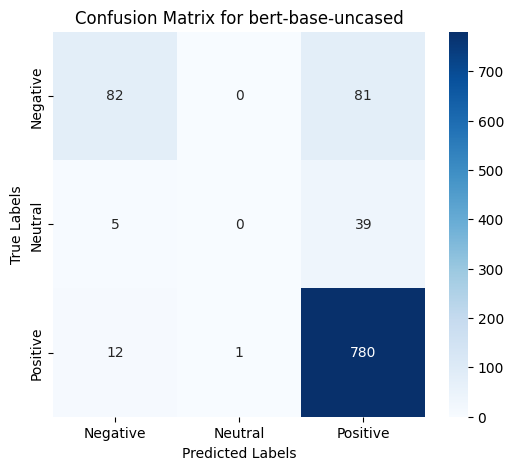

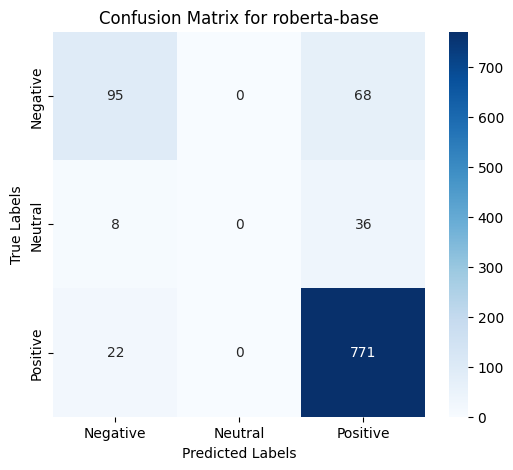

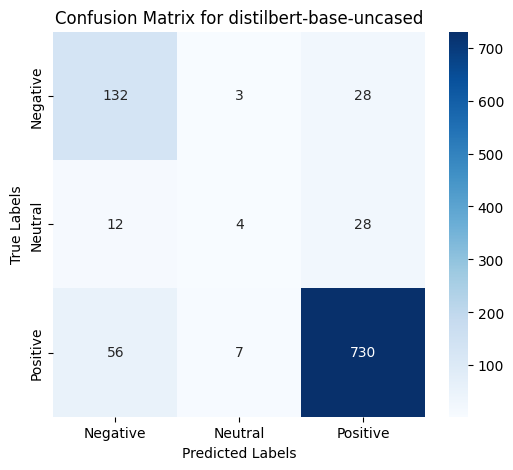

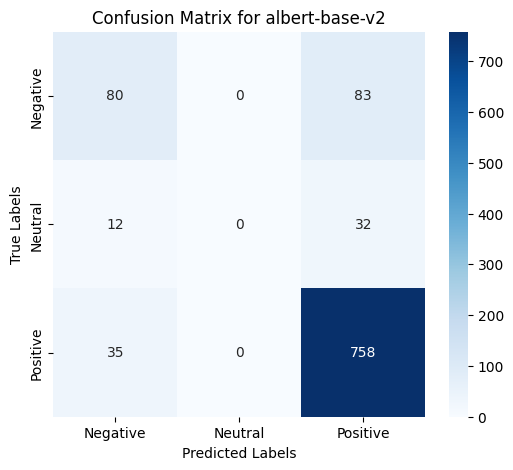

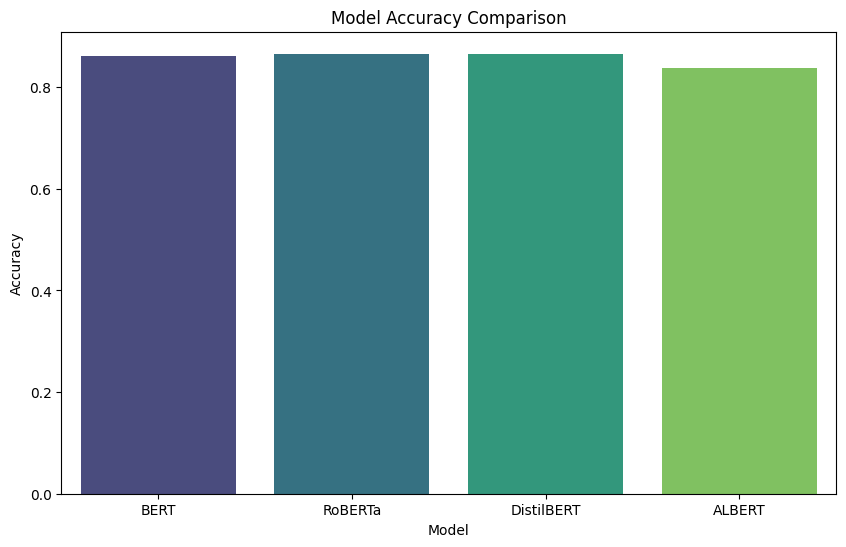

In [21]:
# Set device to GPU if available, otherwise fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# BERT
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_accuracy, bert_report = train_and_evaluate_model('bert-base-uncased', train_df, test_df, bert_tokenizer, BertForSequenceClassification)

# RoBERTa
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
roberta_accuracy, roberta_report = train_and_evaluate_model('roberta-base', train_df, test_df, roberta_tokenizer, RobertaForSequenceClassification)

# DistilBERT
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_accuracy, distilbert_report = train_and_evaluate_model('distilbert-base-uncased', train_df, test_df, distilbert_tokenizer, DistilBertForSequenceClassification)

# ALBERT
albert_tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')
albert_accuracy, albert_report = train_and_evaluate_model('albert-base-v2', train_df, test_df, albert_tokenizer, AlbertForSequenceClassification)


# Compare the results
accuracies = {
    'BERT': bert_accuracy,
    'RoBERTa': roberta_accuracy,
    'DistilBERT': distilbert_accuracy,
    'ALBERT': albert_accuracy
}

print(bert_report)
print(roberta_report)
print(distilbert_report)
print(albert_report)

# Bar Plot for Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()



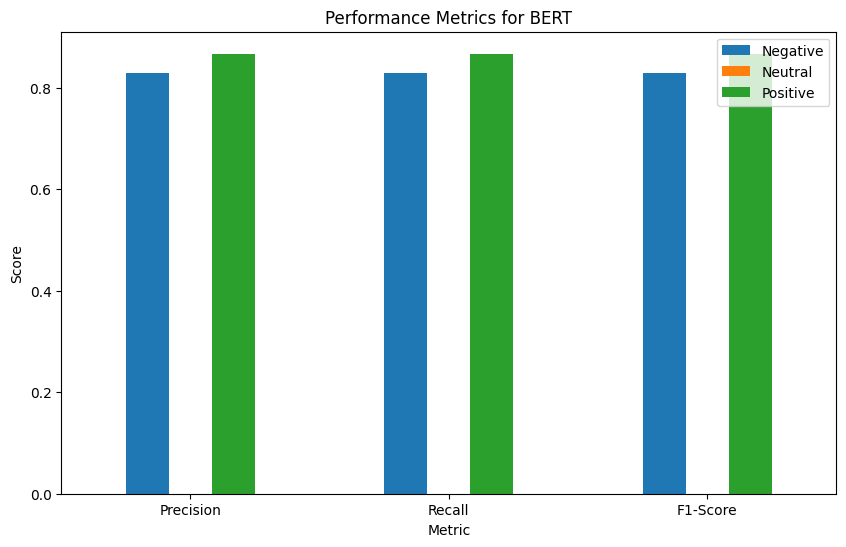

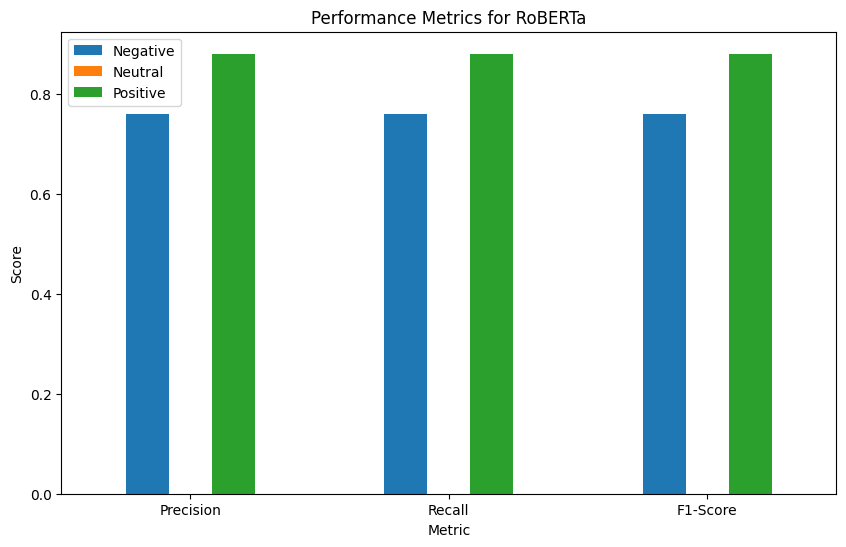

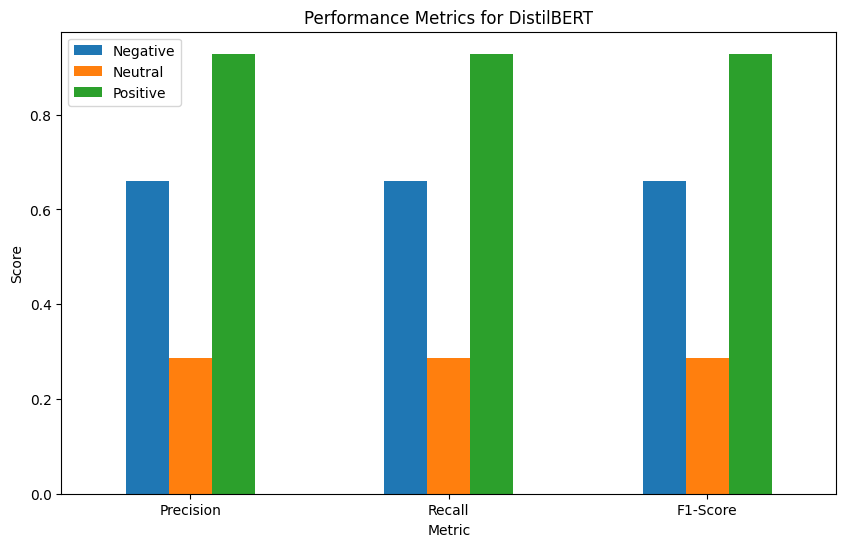

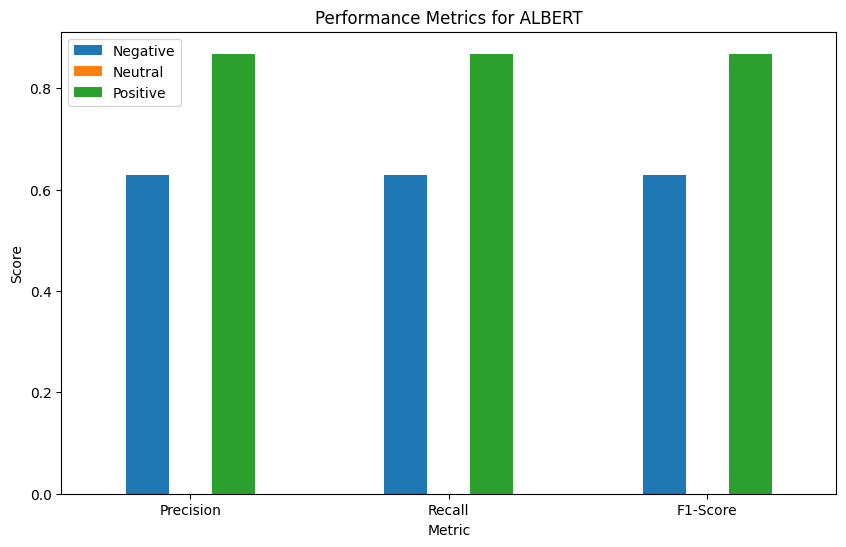

In [22]:
def plot_metrics(report, model_name):
    # Extract Precision, Recall, and F1 scores
    precision = [report[class_name]['precision'] for class_name in ['Negative', 'Neutral', 'Positive']]
    recall = [report[class_name]['recall'] for class_name in ['Negative', 'Neutral', 'Positive']]
    f1_score = [report[class_name]['f1-score'] for class_name in ['Negative', 'Neutral', 'Positive']]

    # Plot precision, recall, f1-score
    metrics_df = pd.DataFrame({
        'Metric': ['Precision', 'Recall', 'F1-Score'],
        'Negative': precision[0], 'Neutral': precision[1], 'Positive': precision[2]
    })

    metrics_df.set_index('Metric', inplace=True)

    metrics_df.plot(kind='bar', figsize=(10, 6))
    plt.title(f"Performance Metrics for {model_name}")
    plt.ylabel("Score")
    plt.xticks(rotation=0)
    plt.show()

# Plot for each model
plot_metrics(bert_report, "BERT")
plot_metrics(roberta_report, "RoBERTa")
plot_metrics(distilbert_report, "DistilBERT")
plot_metrics(albert_report, "ALBERT")


<Figure size 1000x600 with 0 Axes>

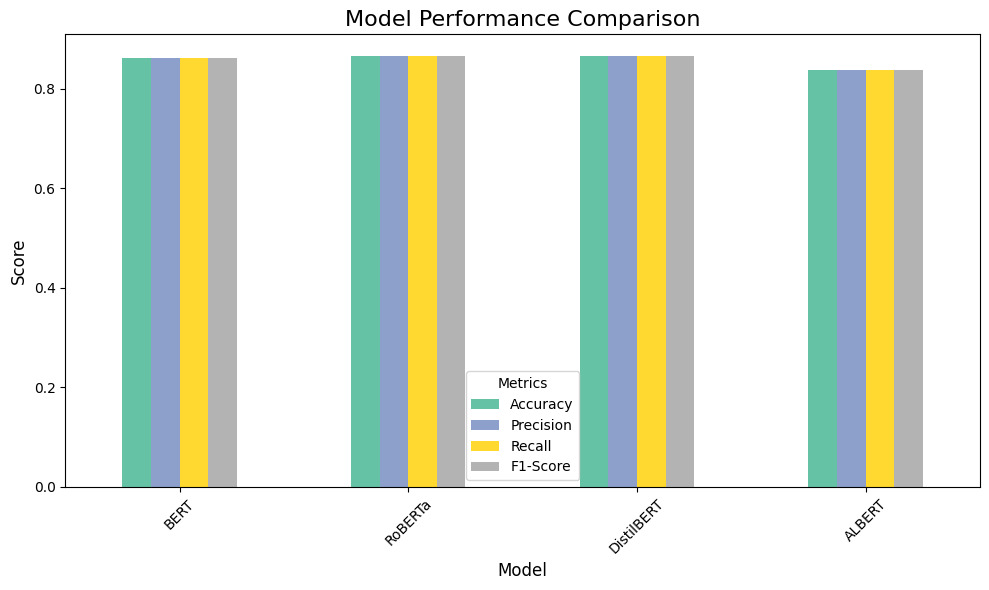

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Extract metrics from classification reports (you might need to adjust these based on your report structure)
def extract_metrics(report):
    # Extract the precision, recall, f1-score for each class, and overall accuracy from the classification report
    metrics = {
        'precision': report['accuracy'],  # You may need to extract the average precision
        'recall': report['accuracy'],     # Extract the average recall
        'f1-score': report['accuracy'],   # Extract the average f1-score
        'accuracy': report['accuracy']    # Extract overall accuracy
    }
    return metrics

# Replace with the actual classification report results
bert_metrics = extract_metrics(bert_report)
roberta_metrics = extract_metrics(roberta_report)
distilbert_metrics = extract_metrics(distilbert_report)
albert_metrics = extract_metrics(albert_report)

# Models and their metrics
models = ['BERT', 'RoBERTa', 'DistilBERT', 'ALBERT']

# Collect the accuracy, precision, recall, and f1 scores
accuracy = [bert_metrics['accuracy'], roberta_metrics['accuracy'], distilbert_metrics['accuracy'], albert_metrics['accuracy']]
precision = [bert_metrics['precision'], roberta_metrics['precision'], distilbert_metrics['precision'], albert_metrics['precision']]
recall = [bert_metrics['recall'], roberta_metrics['recall'], distilbert_metrics['recall'], albert_metrics['recall']]
f1_score = [bert_metrics['f1-score'], roberta_metrics['f1-score'], distilbert_metrics['f1-score'], albert_metrics['f1-score']]

# Create a DataFrame to hold these metrics for easier plotting
import pandas as pd
df_metrics = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_score
})

# Set the size of the figure
plt.figure(figsize=(10, 6))

# Plot the metrics for each model
df_metrics.set_index('Model').plot(kind='bar', figsize=(10, 6), colormap='Set2')

# Add labels and title
plt.title('Model Performance Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Metrics')

# Display the plot
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

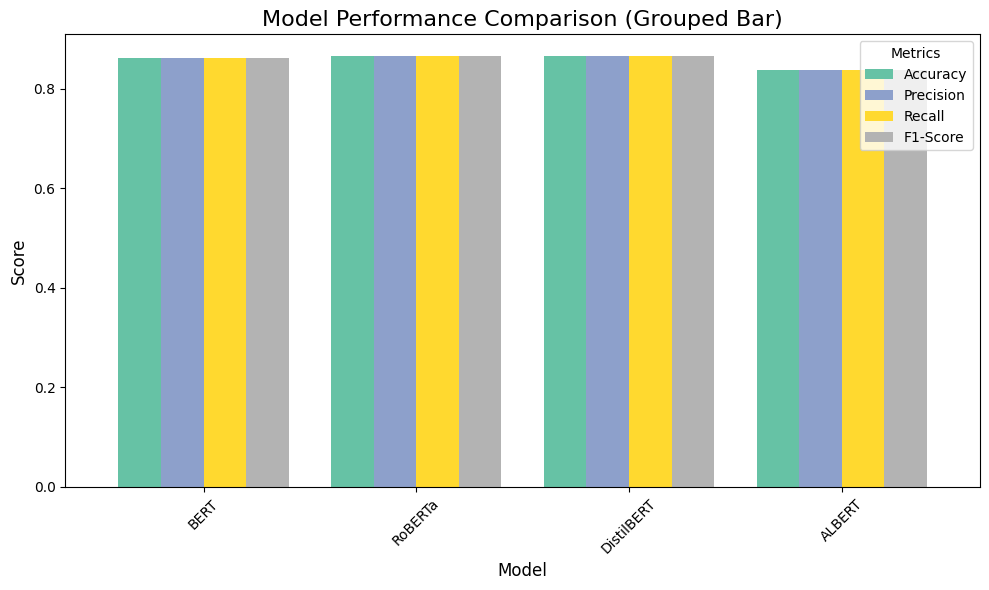

In [24]:
# Grouped Bar Chart for Comparison
plt.figure(figsize=(10, 6))

# Plot the metrics for each model as grouped bars
df_metrics.set_index('Model').plot(kind='bar', figsize=(10, 6), width=0.8, colormap='Set2')

# Add labels and title
plt.title('Model Performance Comparison (Grouped Bar)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Metrics')

# Display the plot
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

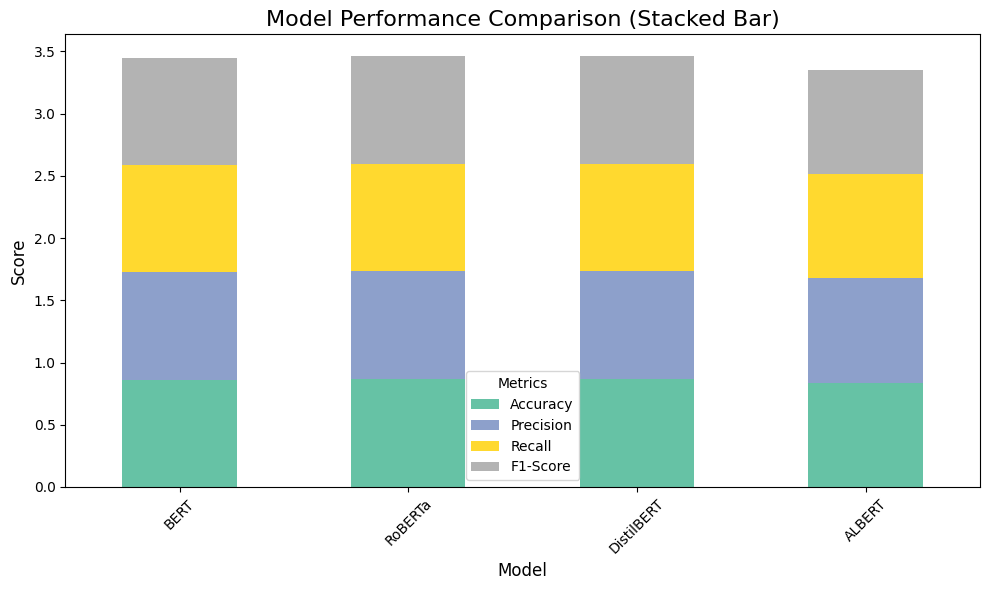

In [25]:
# Stacked Bar Chart for Comparison
plt.figure(figsize=(10, 6))

# Plot the metrics as stacked bars
df_metrics.set_index('Model').plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

# Add labels and title
plt.title('Model Performance Comparison (Stacked Bar)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Metrics')

# Display the plot
plt.tight_layout()
plt.show()


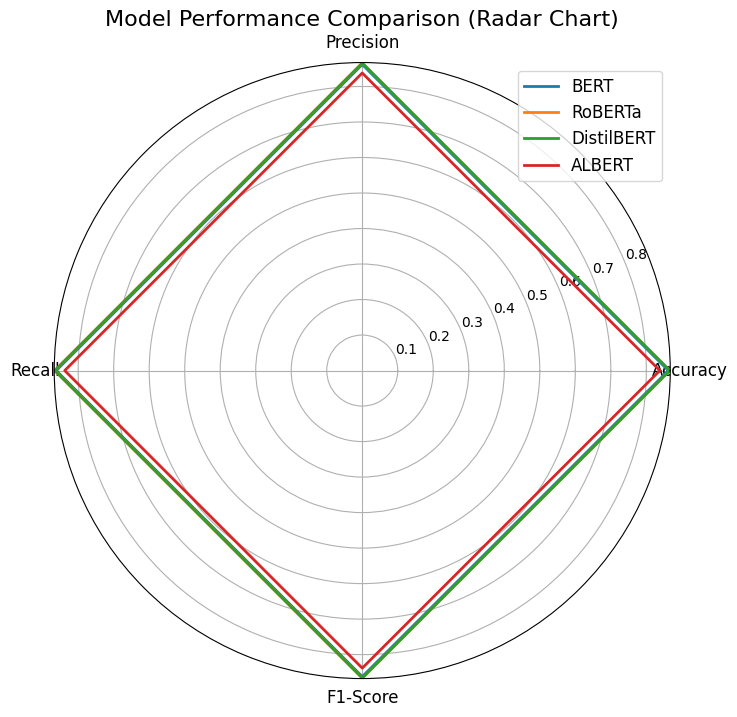

In [26]:
import numpy as np

# Radar Chart function
def plot_radar_chart(df, models):
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # Close the circle

    # Create a figure
    plt.figure(figsize=(8, 8))

    for model in models:
        values = df.loc[model].values.tolist()
        values += values[:1]

        plt.polar(angles, values, label=model, linewidth=2, linestyle='solid')

    # Labels for each axis
    plt.xticks(angles[:-1], categories, fontsize=12)

    plt.title('Model Performance Comparison (Radar Chart)', fontsize=16)
    plt.legend(loc='upper right', fontsize=12)

    plt.show()

# Plotting the Radar Chart
df_metrics.set_index('Model', inplace=True)
plot_radar_chart(df_metrics, models)


In [29]:
from transformers import BertForSequenceClassification, RobertaForSequenceClassification, DistilBertForSequenceClassification, AlbertForSequenceClassification
from transformers import BertTokenizer, RobertaTokenizer, DistilBertTokenizer, AlbertTokenizer

# Save the model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_name):
    # Create a directory to save the model and tokenizer
    save_directory = f'/content/drive/MyDrive/Final year project/saved_models/{model_name}'

    # Save model
    model.save_pretrained(save_directory)

    # Save tokenizer
    tokenizer.save_pretrained(save_directory)

    print(f"Model and tokenizer for {model_name} saved to {save_directory}")

# Initialize models and tokenizers
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2) # Replace num_labels with the number of classes in your task
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)  # Replace num_labels
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)  # Replace num_labels
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

albert_model = AlbertForSequenceClassification.from_pretrained('albert-base-v2', num_labels=2)  # Replace num_labels
albert_tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')

# Example: Save BERT model and tokenizer
save_model_and_tokenizer(bert_model, bert_tokenizer, 'bert')

# Example: Save RoBERTa model and tokenizer
save_model_and_tokenizer(roberta_model, roberta_tokenizer, 'roberta')

# Example: Save DistilBERT model and tokenizer
save_model_and_tokenizer(distilbert_model, distilbert_tokenizer, 'distilbert')

# Example: Save ALBERT model and tokenizer
save_model_and_tokenizer(albert_model, albert_tokenizer, 'albert')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

Model and tokenizer for bert saved to /content/drive/MyDrive/Final year project/saved_models/bert
Model and tokenizer for roberta saved to /content/drive/MyDrive/Final year project/saved_models/roberta
Model and tokenizer for distilbert saved to /content/drive/MyDrive/Final year project/saved_models/distilbert
Model and tokenizer for albert saved to /content/drive/MyDrive/Final year project/saved_models/albert


In [30]:
from transformers import BertForSequenceClassification, RobertaForSequenceClassification, DistilBertForSequenceClassification, AlbertForSequenceClassification
from transformers import BertTokenizer, RobertaTokenizer, DistilBertTokenizer, AlbertTokenizer

# Load the saved model and tokenizer
def load_model_and_tokenizer(model_name):
    save_directory = f'./saved_models/{model_name}'

    # Load model
    model = BertForSequenceClassification.from_pretrained(save_directory) if model_name == 'bert' else \
            RobertaForSequenceClassification.from_pretrained(save_directory) if model_name == 'roberta' else \
            DistilBertForSequenceClassification.from_pretrained(save_directory) if model_name == 'distilbert' else \
            AlbertForSequenceClassification.from_pretrained(save_directory)

    # Load tokenizer
    tokenizer = BertTokenizer.from_pretrained(save_directory) if model_name == 'bert' else \
                RobertaTokenizer.from_pretrained(save_directory) if model_name == 'roberta' else \
                DistilBertTokenizer.from_pretrained(save_directory) if model_name == 'distilbert' else \
                AlbertTokenizer.from_pretrained(save_directory)

    return model, tokenizer

# Example: Load BERT model and tokenizer
bert_model, bert_tokenizer = load_model_and_tokenizer('bert')

# Example: Load RoBERTa model and tokenizer
roberta_model, roberta_tokenizer = load_model_and_tokenizer('roberta')

# Example: Load DistilBERT model and tokenizer
distilbert_model, distilbert_tokenizer = load_model_and_tokenizer('distilbert')

# Example: Load ALBERT model and tokenizer
albert_model, albert_tokenizer = load_model_and_tokenizer('albert')


In [31]:
# Example: Verify the loaded BERT model
input_text = "I love this product!"
inputs = bert_tokenizer(input_text, return_tensors='pt')
output = bert_model(**inputs)

print(f"Model Output: {output}")


Model Output: SequenceClassifierOutput(loss=None, logits=tensor([[0.0287, 0.2874]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
